# BMW Global Sales Analysis & Predictive Modeling
This notebook explores the BMW sales dataset to analyze regional performance, electric vehicle (EV) adoption, and revenue trends.
Furthermore, an end-to-end Machine Learning pipeline is implemented to predict vehicle sales using a Random Forest Regressor and evaluate performance.

### 1. Importing Required Libraries
Load essential libraries for data manipulation (`pandas`, `numpy`) and visualization (`matplotlib`, `seaborn`).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 2. Loading the Dataset
Read the BMW global sales CSV dataset into a pandas DataFrame.

In [2]:
df = pd.read_csv('bmw_sales.csv')

#### Data Peek
Quickly preview the first few rows of the updated dataframe.

In [3]:
df.head()

,Year,Month,Region,Model,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index
0,2018,1,Europe,3 Series,7822,47482,371404204,0.011,19.12,3.5,1.0
1,2018,1,Europe,5 Series,10280,61685,634121800,0.019,19.12,3.5,1.0
2,2018,1,Europe,X3,3105,58433,181434465,0.022,19.12,3.5,1.0
3,2018,1,Europe,X5,7420,67955,504226100,0.021,19.12,3.5,1.0
4,2018,1,Europe,X7,8474,92300,782150200,0.035,19.12,3.5,1.0


### Data Structural Overview
Check the dimensions of the dataset (number of rows and columns).

In [4]:
df.shape

(3072, 11)

### Statistical Summary
Generate descriptive statistics for numerical columns to understand scale, spread, and central tendencies.

In [5]:
df.describe()

,Year,Month,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index
count,3072.000000,3072.000000,3072.000000,3072.000000,3.072000e+03,3072.000000,3072.000000,3072.000000,3072.000000
mean,2021.500000,6.500000,7980.288086,63854.561523,5.113995e+08,0.107572,14.660234,3.057526,1.176224
std,2.291661,3.452615,3174.917444,14655.891299,2.431185e+08,0.058099,5.334604,1.018103,0.118123
min,2018.000000,1.000000,2379.000000,40011.000000,1.045314e+08,-0.015000,5.090000,0.100000,0.920000
25%,2019.750000,3.750000,5225.500000,54500.250000,3.125504e+08,0.057000,12.275000,2.370000,1.080000
50%,2021.500000,6.500000,7985.500000,63493.000000,4.808690e+08,0.108000,16.260000,3.060000,1.180000
75%,2023.250000,9.250000,10528.250000,71489.500000,6.709141e+08,0.157250,18.932500,3.852500,1.270000
max,2025.000000,12.000000,15914.000000,93994.000000,1.433482e+09,0.223000,20.970000,5.820000,1.410000


### Data Information
Check data types and non-null counts to ensure data quality and identify null values.

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3072 entries, 0 to 3071
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Year              3072 non-null   int64  
 1   Month             3072 non-null   int64  
 2   Region            3072 non-null   str    
 3   Model             3072 non-null   str    
 4   Units_Sold        3072 non-null   int64  
 5   Avg_Price_EUR     3072 non-null   int64  
 6   Revenue_EUR       3072 non-null   int64  
 7   BEV_Share         3072 non-null   float64
 8   Premium_Share     3072 non-null   float64
 9   GDP_Growth        3072 non-null   float64
 10  Fuel_Price_Index  3072 non-null   float64
dtypes: float64(4), int64(5), str(2)
memory usage: 264.1 KB


### Regional Scope
Identify the unique regions present in the sales dataset.

In [7]:
df['Region'].unique()

<StringArray>
['Europe', 'China', 'USA', 'RestOfWorld']
Length: 4, dtype: str

### 3. Feature Engineering: Date Formatting
Create a unified datetime feature from `Year` and `Month` to facilitate time-series analysis.

In [8]:
df['Date'] = pd.to_datetime(df['Year'].astype(str) + '-' + df['Month'].astype(str))

#### Data Peek
Quickly preview the first few rows of the updated dataframe.

In [9]:
df.head()

,Year,Month,Region,Model,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index,Date
0,2018,1,Europe,3 Series,7822,47482,371404204,0.011,19.12,3.5,1.0,2018-01-01
1,2018,1,Europe,5 Series,10280,61685,634121800,0.019,19.12,3.5,1.0,2018-01-01
2,2018,1,Europe,X3,3105,58433,181434465,0.022,19.12,3.5,1.0,2018-01-01
3,2018,1,Europe,X5,7420,67955,504226100,0.021,19.12,3.5,1.0,2018-01-01
4,2018,1,Europe,X7,8474,92300,782150200,0.035,19.12,3.5,1.0,2018-01-01


### Revenue Validation
Validate the integrity of the data by ensuring that `Units_Sold` multiplied by `Avg_Price_EUR` matches the reported `Revenue_EUR`.

In [10]:
df["calc_revenue"] = df["Units_Sold"] * df["Avg_Price_EUR"]
(df["Revenue_EUR"] - df["calc_revenue"]).sum()

np.int64(0)

### 4. Exploratory Data Analysis (EDA)
#### Overall Sales Trend
Visualize the aggregate sales volume over the given time period.

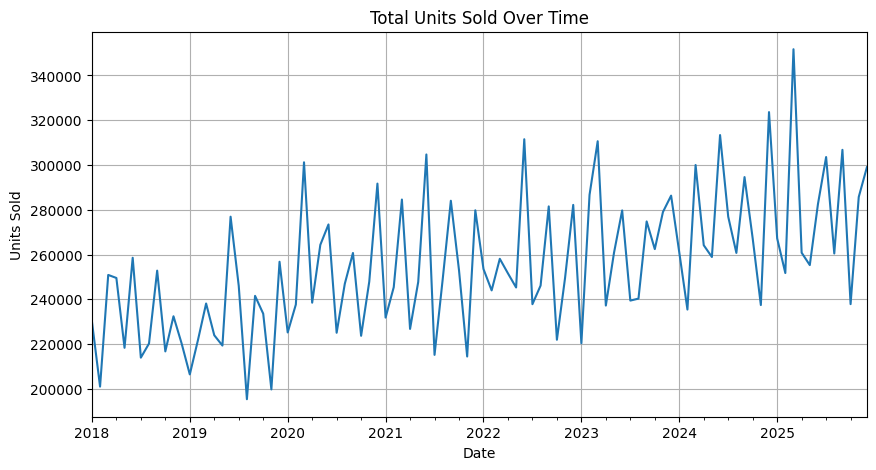

In [11]:
sales_trend = df.groupby("Date")["Units_Sold"].sum()
sales_trend.plot(figsize=(10, 5))
plt.title("Total Units Sold Over Time")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.grid()
plt.show()

#### Total Revenue by Region
Calculate and rank total revenue generated across different global regions.

In [12]:
df.groupby("Region")["Revenue_EUR"].sum().sort_values(ascending=False)

Region
China          401755020483
RestOfWorld    391071034606
USA            389314290428
Europe         388878952601
Name: Revenue_EUR, dtype: int64

#### Total Units Sold by Region
Calculate and rank the absolute volume of cars sold per region.

In [13]:
df.groupby("Region")["Units_Sold"].sum().sort_values(ascending=False)

Region
China          6256750
RestOfWorld    6113872
USA            6099647
Europe         6045176
Name: Units_Sold, dtype: int64

#### Total Units Sold by Region
Calculate and rank the absolute volume of cars sold per region.

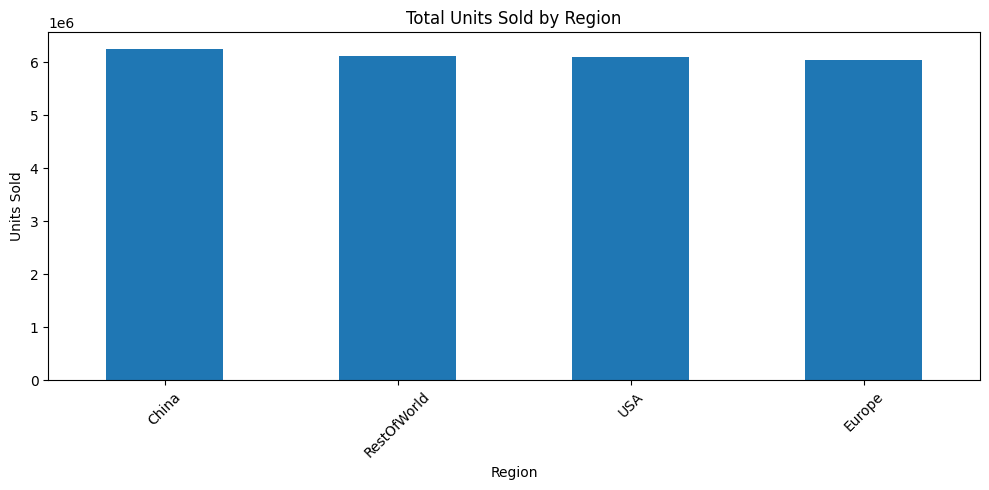

In [14]:
region_sales = df.groupby("Region")["Units_Sold"].sum().sort_values(ascending=False)
region_sales.plot(kind='bar', figsize=(10, 5))
plt.title("Total Units Sold by Region")
plt.xlabel("Region")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Regional Sales Trajectory
Plot the monthly units sold separated by region to track individual market growth and seasonality.

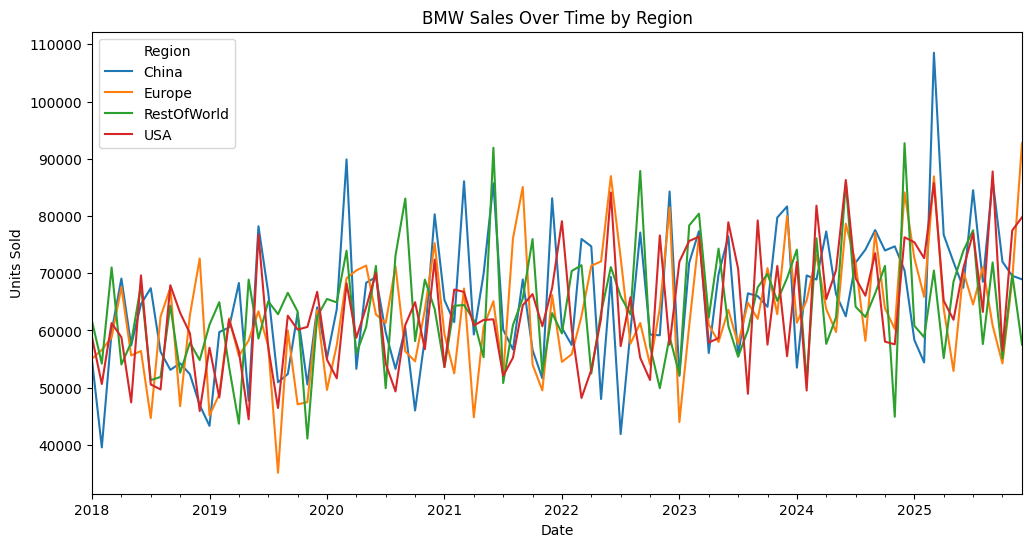

In [15]:
import matplotlib.pyplot as plt

region_time = df.groupby(["Date", "Region"])["Units_Sold"].sum().unstack()

region_time.plot(figsize=(12, 6))

plt.title("BMW Sales Over Time by Region")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.legend(title="Region")
plt.show()

#### Electric Vehicle (BEV) Adoption Trend
Analyze the year-over-year growth in Battery Electric Vehicle (BEV) market share.

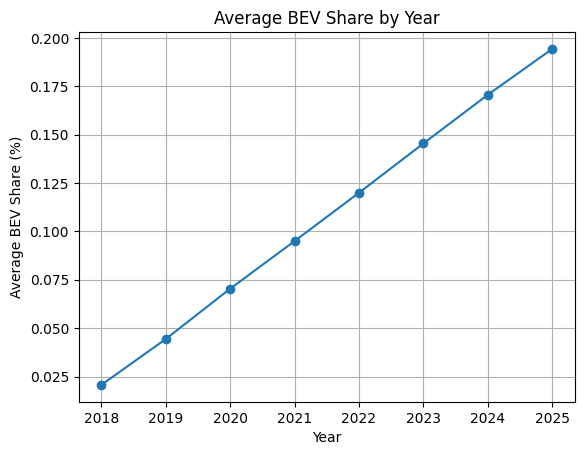

In [16]:
ev_trend = df.groupby("Year")["BEV_Share"].mean()
ev_trend.plot(marker="o")
plt.title("Average BEV Share by Year")
plt.xlabel("Year")
plt.ylabel("Average BEV Share (%)")
plt.xticks(df["Year"].unique())
plt.grid()
plt.show()

#### Revenue Trajectory by Region
Examine how average regional revenues have evolved over time.

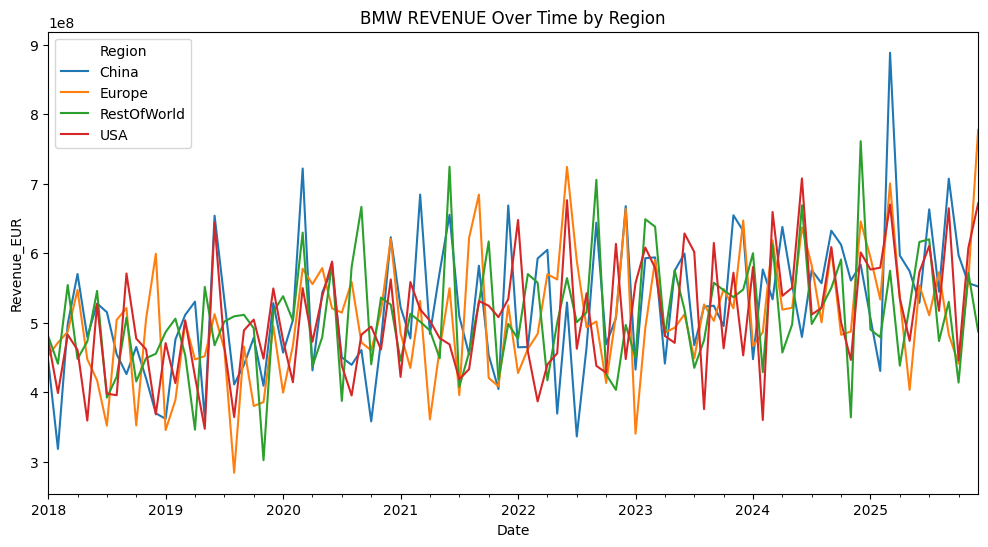

In [17]:
price_trend = df.groupby(["Date", "Region"])["Revenue_EUR"].mean().unstack()
price_trend.plot(figsize=(12, 6))
plt.title("BMW REVENUE Over Time by Region")
plt.xlabel("Date")
plt.ylabel("Revenue_EUR")
plt.show()

#### EV Adoption vs. Fuel Prices
Overlay BEV share alongside fuel price indices to observe potential correlations.

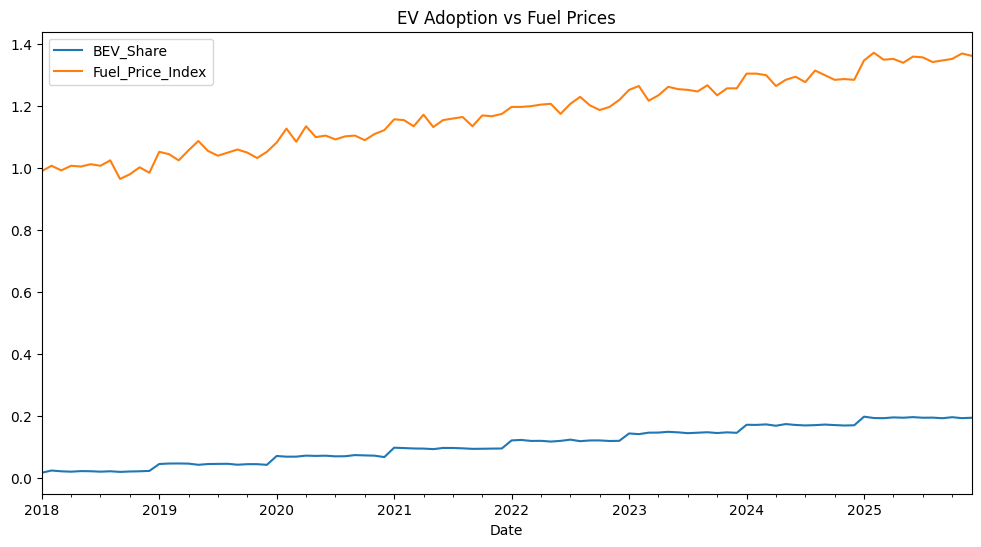

In [18]:
ev_vs_fuel = df.groupby("Date")[["BEV_Share", "Fuel_Price_Index"]].mean()
ev_vs_fuel.plot(figsize=(12, 6))
plt.title("EV Adoption vs Fuel Prices")
plt.show()

#### Average Vehicle Price per Region
Compare the average selling price of BMW vehicles across the four primary markets.

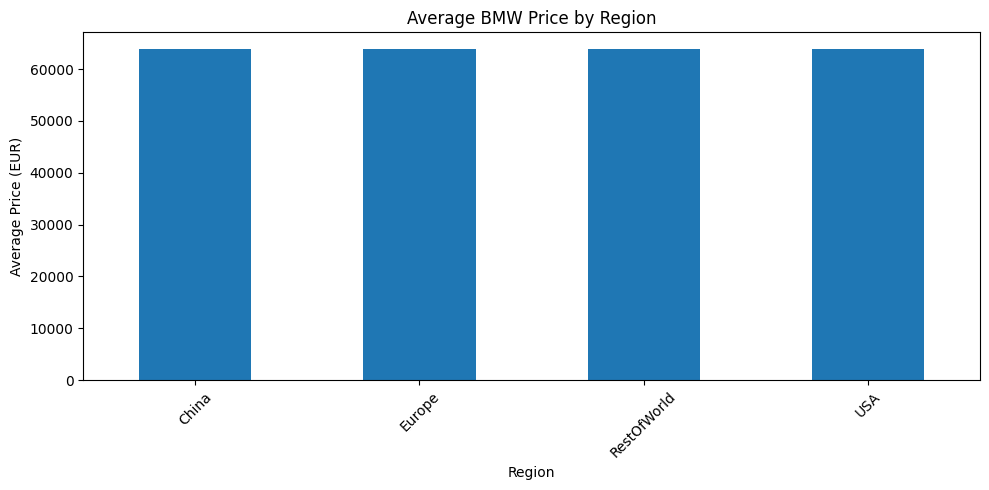

In [19]:
region_avgPrice = df.groupby("Region")["Avg_Price_EUR"].mean()
region_avgPrice.plot(kind='bar', figsize=(10, 5))
plt.title("Average BMW Price by Region")
plt.xlabel("Region")
plt.ylabel("Average Price (EUR)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Correlation: Sales Volume vs. Price
Analyze the statistical correlation between units sold and average vehicle price.

In [20]:
df[["Units_Sold", "Avg_Price_EUR"]].corr()

,Units_Sold,Avg_Price_EUR
Units_Sold,1.000000,0.039163
Avg_Price_EUR,0.039163,1.000000


#### Correlation: Sales Volume vs. Revenue
Assess the correlation between the volume of units sold and total revenue.

In [21]:
df[["Units_Sold", "Revenue_EUR"]].corr()

,Units_Sold,Revenue_EUR
Units_Sold,1.000000,0.856358
Revenue_EUR,0.856358,1.000000


#### Sales vs. Revenue by Model
Visualize the clustering of different models based on their sales volume and revenue generation.

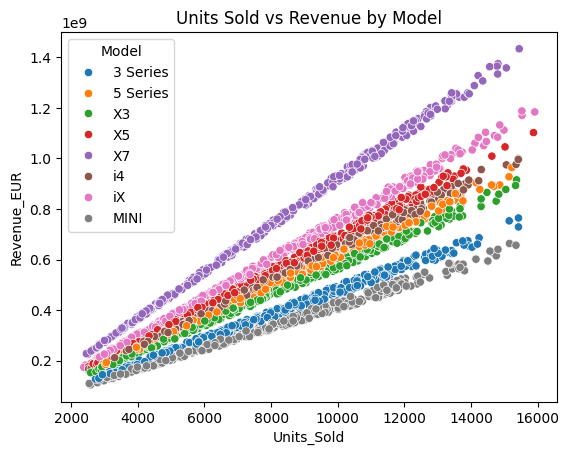

In [22]:
import seaborn as sns

sns.scatterplot(data=df, x="Units_Sold", y="Revenue_EUR", hue="Model")

plt.title("Units Sold vs Revenue by Model")
plt.show()

#### Regional Revenue Breakdown by Model
Create a pivot table summarizing total revenue for each model within each region (in billions of EUR).

In [23]:
model_region = (
    df.pivot_table(values="Revenue_EUR", index="Model", columns="Region", aggfunc="sum")
    / 1e9
)

#### Heatmap of Regional Model Revenue
Visualize the pivot table as a heatmap to easily identify the strongest product-market fits.

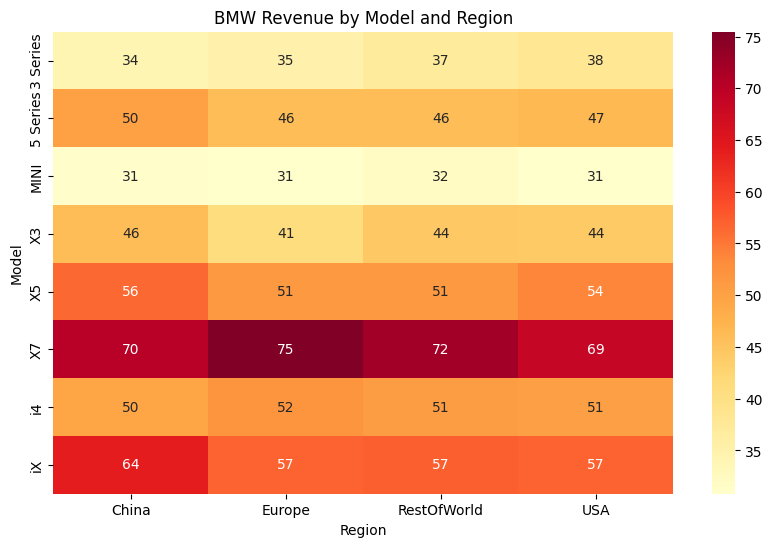

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.heatmap(model_region, cmap="YlOrRd", annot=True, fmt=".0f")

plt.title("BMW Revenue by Model and Region")
plt.xlabel("Region")
plt.ylabel("Model")

plt.show()

#### Data Peek
Quickly preview the first few rows of the updated dataframe.

In [25]:
df.head()

,Year,Month,Region,Model,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index,Date,calc_revenue
0,2018,1,Europe,3 Series,7822,47482,371404204,0.011,19.12,3.5,1.0,2018-01-01,371404204
1,2018,1,Europe,5 Series,10280,61685,634121800,0.019,19.12,3.5,1.0,2018-01-01,634121800
2,2018,1,Europe,X3,3105,58433,181434465,0.022,19.12,3.5,1.0,2018-01-01,181434465
3,2018,1,Europe,X5,7420,67955,504226100,0.021,19.12,3.5,1.0,2018-01-01,504226100
4,2018,1,Europe,X7,8474,92300,782150200,0.035,19.12,3.5,1.0,2018-01-01,782150200


#### Average Price by Model
Compare the average pricing tiers across the BMW model lineup.

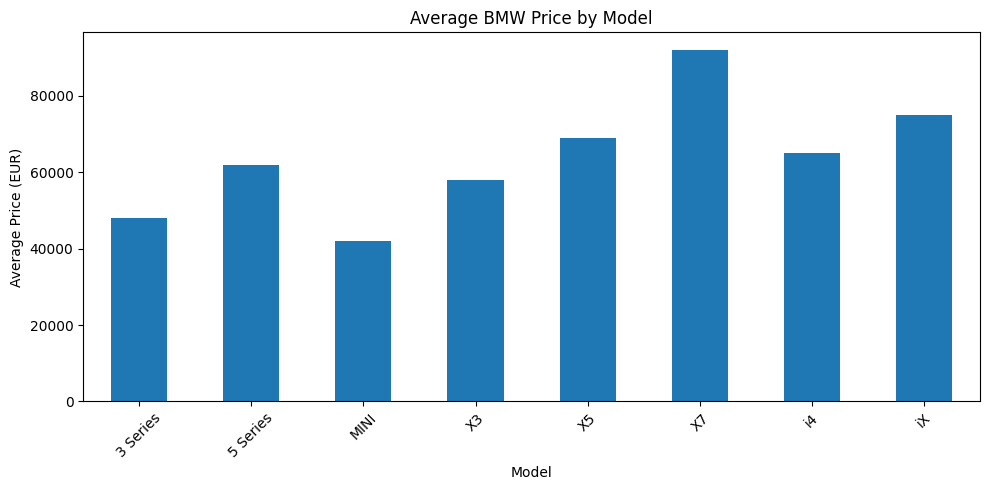

In [26]:
model_price = df.groupby("Model")["Avg_Price_EUR"].mean()
model_price.plot(kind='bar', figsize=(10, 5))
plt.title("Average BMW Price by Model")
plt.xlabel("Model")
plt.ylabel("Average Price (EUR)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Data Peek
Quickly preview the first few rows of the updated dataframe.

In [27]:
df.head()

,Year,Month,Region,Model,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index,Date,calc_revenue
0,2018,1,Europe,3 Series,7822,47482,371404204,0.011,19.12,3.5,1.0,2018-01-01,371404204
1,2018,1,Europe,5 Series,10280,61685,634121800,0.019,19.12,3.5,1.0,2018-01-01,634121800
2,2018,1,Europe,X3,3105,58433,181434465,0.022,19.12,3.5,1.0,2018-01-01,181434465
3,2018,1,Europe,X5,7420,67955,504226100,0.021,19.12,3.5,1.0,2018-01-01,504226100
4,2018,1,Europe,X7,8474,92300,782150200,0.035,19.12,3.5,1.0,2018-01-01,782150200


### 5. Machine Learning Pipeline
#### Feature Selection
Define the independent variables (`X`) and the target variable (`y`), which in this case is `Units_Sold`.

In [28]:
features = [
    "Region",
    "Model",
    "Avg_Price_EUR",
    "GDP_Growth",
    "Fuel_Price_Index",
    "Premium_Share",
    "BEV_Share",
    "Month",
    "Year",
]

X = df[features]
y = df["Units_Sold"]

#### Data Preprocessing: Categorical Encoding
Convert categorical string variables (`Region`, `Model`) into numerical labels suitable for machine learning algorithms.

In [29]:
from sklearn.preprocessing import LabelEncoder

region_encoder = LabelEncoder()
model_encoder = LabelEncoder()

X['Region'] = region_encoder.fit_transform(X['Region'])
X['Model'] = model_encoder.fit_transform(X['Model'])


#### Train-Test Split
Divide the dataset into training (80%) and testing (20%) subsets to evaluate the model on unseen data.

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#### Data Preprocessing: Feature Scaling
Standardize numerical features by removing the mean and scaling to unit variance.

In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### Model Training: Random Forest Regressor
Initialize and train a Random Forest ensemble model to predict vehicle sales.

In [32]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=200, random_state=42)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

#### Model Evaluation: Regression Metrics
Evaluate continuous prediction performance using Mean Absolute Error (MAE) and R-squared ($R^2$) score.

In [33]:
from sklearn.metrics import mean_absolute_error, r2_score

pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, pred))
print("R2:", r2_score(y_test, pred))

MAE: 2700.0559105691054
R2: -0.026534488951353463


#### Actual vs. Predicted Scatter Plot
Visualize the alignment of the model's predictions against the actual test values. A perfect model would align along the red dashed line.

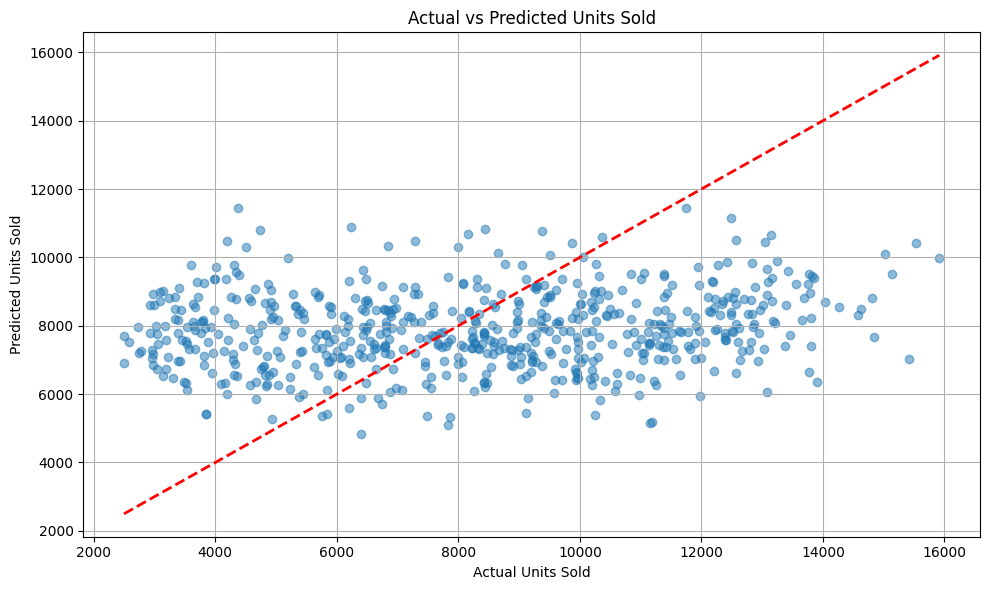

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test, pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Units Sold')
plt.ylabel('Predicted Units Sold')
plt.title('Actual vs Predicted Units Sold')
plt.grid(True)
plt.tight_layout()
plt.show()


#### Model Evaluation: Classification Transformation
Transform the continuous sales predictions into discrete categories (Low, Medium, High) based on quantiles, and evaluate categorical accuracy using a classification report.

In [35]:
from sklearn.metrics import classification_report
import numpy as np

def categorize(values, reference_values=None):
    if reference_values is None:
        reference_values = values
    q33 = np.percentile(reference_values, 33)
    q66 = np.percentile(reference_values, 66)
    categories = []
    for v in values:
        if v < q33:
            categories.append('Low')
        elif v < q66:
            categories.append('Medium')
        else:
            categories.append('High')
    return categories

y_test_cat = categorize(y_test)
pred_cat = categorize(pred, reference_values=y_test)


print("Classification Report (categorized as Low/Medium/High):\n")
print(classification_report(y_test_cat, pred_cat))


Classification Report (categorized as Low/Medium/High):

              precision    recall  f1-score   support

        High       0.40      0.05      0.09       209
         Low       0.40      0.13      0.20       203
      Medium       0.33      0.85      0.48       203

    accuracy                           0.34       615
   macro avg       0.38      0.34      0.25       615
weighted avg       0.38      0.34      0.25       615



#### Feature Importance Extraction
Extract the internal feature importances from the Random Forest model to understand what drives vehicle sales.

In [36]:
import pandas as pd

importance = pd.Series(model.feature_importances_, index=X_train.columns)

importance = importance.sort_values(ascending=False)

print(importance)

Avg_Price_EUR       0.253040
BEV_Share           0.202399
Premium_Share       0.131714
GDP_Growth          0.121961
Fuel_Price_Index    0.088298
Month               0.080660
Model               0.069487
Region              0.032692
Year                0.019751
dtype: float64


#### Feature Importance Visualization
Plot the relative influence of each feature on the model's predictions.

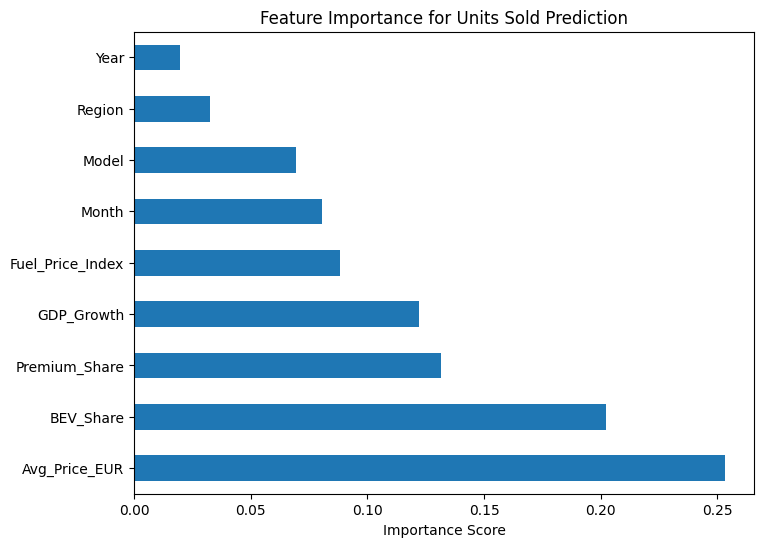

In [37]:
import matplotlib.pyplot as plt

importance.plot(kind="barh", figsize=(8, 6))

plt.title("Feature Importance for Units Sold Prediction")
plt.xlabel("Importance Score")
plt.show()

#### Residual Analysis: Statistics
Calculate the raw prediction errors (residuals) and display their primary statistics (mean, standard deviation).

In [38]:
residuals = y_test - pred

print("Residual Statistics:")
print(f"Mean: {residuals.mean():.2f}")
print(f"Std Dev: {residuals.std():.2f}")
print(f"Min: {residuals.min():.2f}")
print(f"Max: {residuals.max():.2f}")


Residual Statistics:
Mean: 390.85
Std Dev: 3172.78
Min: -7075.41
Max: 8404.02


#### Residual Diagnostics
Visualize residual behavior using a scatter plot, histogram, Q-Q plot, and actuals plot to check for homoscedasticity and normality of errors.

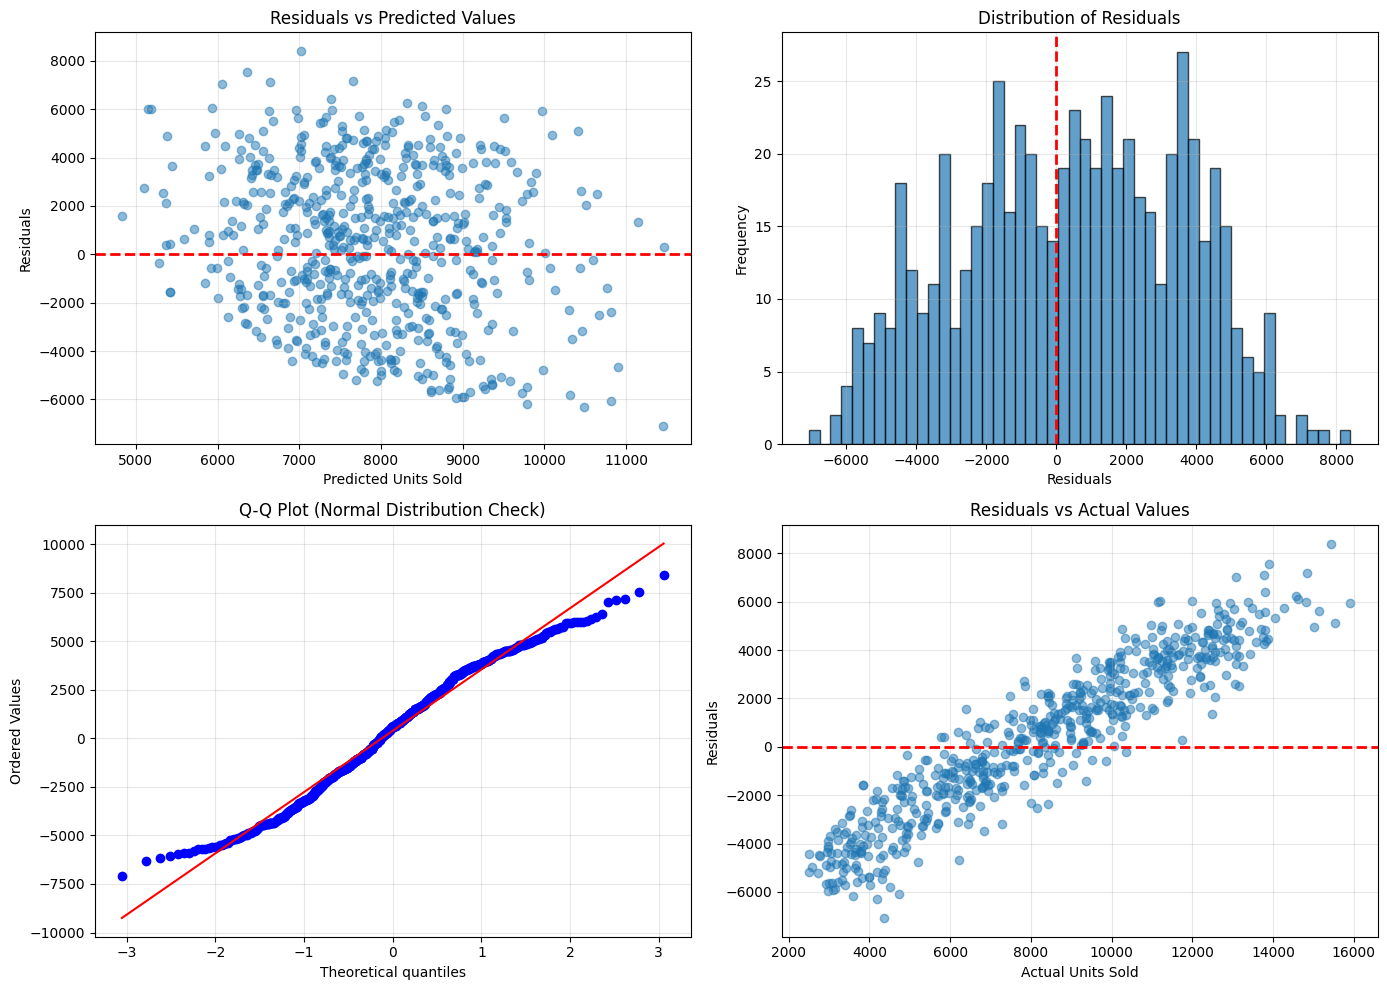

In [39]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].scatter(pred, residuals, alpha=0.5)
axes[0, 0].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0, 0].set_xlabel('Predicted Units Sold')
axes[0, 0].set_ylabel('Residuals')
axes[0, 0].set_title('Residuals vs Predicted Values')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
axes[0, 1].axvline(x=0, color='r', linestyle='--', lw=2)
axes[0, 1].set_xlabel('Residuals')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution of Residuals')
axes[0, 1].grid(True, alpha=0.3)

from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot (Normal Distribution Check)')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].scatter(y_test, residuals, alpha=0.5)
axes[1, 1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1, 1].set_xlabel('Actual Units Sold')
axes[1, 1].set_ylabel('Residuals')
axes[1, 1].set_title('Residuals vs Actual Values')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
